In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [ ]:
tf.random.set_seed(870)

In [ ]:
## Mount to drive to access image data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Change directory
main_dir = '/content/drive/MyDrive/Data Problems/Covid19-dataset'
train_dir = os.path.join(main_dir, 'train')
test_dir = os.path.join(main_dir, 'test')

# Loading Data and Visualization

In [ ]:
def display_images(ds): # Function to display a 3x3 of example images from a DS

  images, labels = next(iter(ds)) # take one batch
  if len(labels.shape) == 0: # create a batch size of 9 if no batch size exist
    ds_b = ds.batch(9)
  else: # Rebatch to 9 if batch size does exist
    ds_b = ds.rebatch(9)

  plt.figure(figsize=(5,5)) # Create the figure
  for image, label in ds_b.take(1): # take one batch of images
    for i in range(9):
      ax = plt.subplot(3, 3, i+1) # plot images in a 3x3 grid
      plt.imshow(np.array(image[i]).astype('uint8'))
      plt.title(int(label[i]))

In [ ]:
## Load Training Data
train = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(256,256),
    seed=1,
)

## Load Validation Data
val = keras.utils.image_dataset_from_directory(
    test_dir,
    validation_split = 0.5,
    subset = 'validation',
    image_size=(256,256),
    seed=1)

# Load Testing Data
test = keras.utils.image_dataset_from_directory(
    test_dir,
    validation_split = 0.5,
    subset = 'training',
    image_size=(256,256),
    seed=1)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Using 33 files for validation.
Found 66 files belonging to 3 classes.
Using 33 files for training.


In [ ]:
# @title
# True values from image data

y_train = []
for im, label in train: # Get the labels from each batch
  y_train.append(label) # store the labels in y_train
y_train = np.concatenate(y_train, axis=0) # Concatenate the batches' labels

y_val = []
for im, label in val:
  y_val.append(label)
y_val = np.concatenate(y_val, axis=0)

y_test = []
for im, label in test:
  y_test.append(label)
y_test = np.concatenate(y_test, axis=0)

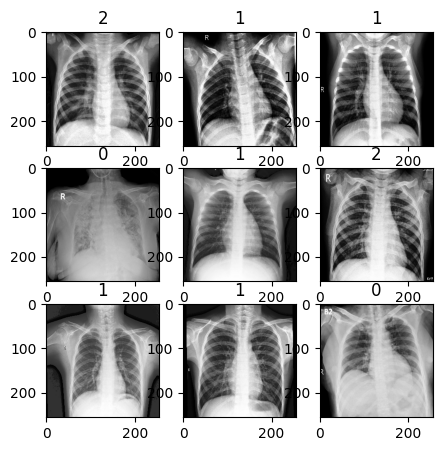

In [ ]:
## Visualize Train Data
display_images(train)

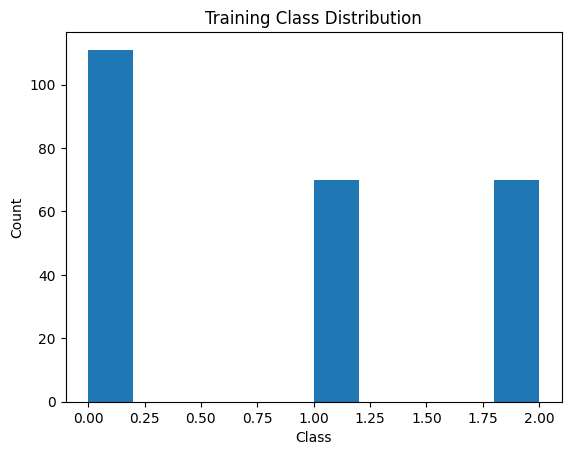

In [ ]:
## Distribution of the training data target variable
plt.hist(y_train)
plt.title('Training Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
## Prepare Data for Modeling
#AUTOTUNE = tf.data.AUTOTUNE
#train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
#val = val.cache().prefetch(buffer_size=AUTOTUNE)
#test = test.cache().prefetch(buffer_size=AUTOTUNE)

## Normalize the Data
normalization_layer = keras.layers.Rescaling(1./255)
train_norm = train.map(lambda x, y: (normalization_layer(x), y))
val_norm = val.map(lambda x, y: (normalization_layer(x), y))
test_norm = test.map(lambda x, y: (normalization_layer(x), y))

# Simple ANN

In [ ]:
## Function to plot the loss by epoch
def loss_plot(history, model='ANN'):
    plt.figure(figsize=(7,5))
    plt.plot(history.history['loss'], label = 'Training Loss') # Plot training loss
    plt.plot(history.history['val_loss'], label = 'Validation Loss') # Plot validation loss
    plt.title(f'{model} Loss by Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

In [ ]:
## Function to plot the accuracy by epoch
def acc_plot(history, model='ANN'):
    plt.figure(figsize=(7,5))
    plt.plot(history.history['accuracy'], label = 'Training Accuracy') # Plot training loss
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy') # Plot validation loss
    plt.title(f'{model} Accuracy by Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

In [ ]:
# Function to collect and plot the metrics for a given model
def model_metrics(model, train, y_train, test, y_test, class_report=False, conf_mat=False, train_set='Training', test_set = 'Test'):
    train_preds = model.predict(train)
    train_preds = np.argmax(train_preds, axis=1)

    test_preds = model.predict(test)
    test_preds = np.argmax(test_preds, axis=1)

    train_prec = precision_score(y_train, train_preds, average='macro') # Macro Precision score
    train_rec = recall_score(y_train, train_preds, average='macro') # Macro Recall score
    train_f1 = f1_score(y_train, train_preds, average='macro') # Macro F1 score

    # precision, recall, and f1 for test
    test_prec = precision_score(y_test, test_preds, average='macro')
    test_rec = recall_score(y_test, test_preds, average='macro')
    test_f1 = f1_score(y_test, test_preds, average='macro')

    # Dataframe with precision, recall, and F1 for train and test sets
    metrics = pd.DataFrame({'Subset': [train_set, test_set],
                           'Precision': [train_prec, test_prec],
                           'Recall': [train_rec, test_rec],
                           'F1': [train_f1, test_f1]})

    # Prints the classification reports for the train and test predictions
    if class_report == True:
        print(f'{train_set} Report:\n', classification_report(y_train, train_preds))
        print(f'{test_set} Report:\n', classification_report(y_test, test_preds))

    ## Generate Confusion Matrix
    if conf_mat == True:
        cm_train = confusion_matrix(y_train, train_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
        disp.plot()
        plt.title(f'{train_set} Confusion Matrix')
        plt.show()

        cm_test = confusion_matrix(y_test, test_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
        disp.plot()
        plt.title(f'{test_set} Confusion Matrix')
        plt.show()

    return metrics.set_index('Subset') # Returns the metrics dataframe

In [ ]:
def plot_metrics(metrics, model_type='ANN', test_set='Test', train_set='Train'):
    metrics.plot(kind='bar')
    plt.title(f'{model_type} Metrics {train_set} vs {test_set}')
    plt.xlabel('Model Metrics')
    plt.ylabel('Score')
    plt.grid(axis='y')
    plt.show()

In [ ]:
# Build a simple ANN model
ann = keras.Sequential([
    layers.Flatten(input_shape=(256,256,3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')]
)

# Compile the model
ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Overview
ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,166,339 (96.00 MB)

 Trainable params: 25,166,339 (96.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the ANN
# Fit the model
ann_history = ann.fit(train_norm, epochs=20, batch_size = 32, validation_data=val_norm)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.5738 - loss: 52.3336 - val_accuracy: 0.7576 - val_loss: 15.4313
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6763 - loss: 15.9268 - val_accuracy: 0.6364 - val_loss: 16.0426
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8449 - loss: 5.2255 - val_accuracy: 0.7576 - val_loss: 10.1706
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.8487 - loss: 7.1426 - val_accuracy: 0.7273 - val_loss: 11.2765
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.8621 - loss: 3.3382 - val_accuracy: 0.7879 - val_loss: 8.9023
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.8729 - loss: 3.7142 - val_accuracy: 0.8182 - val_loss: 9.2892
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.8854 - loss: 3.1970 - val_accuracy: 0.8182 - val_loss: 6.5294
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.9221 - loss: 1.4856 - val_accuracy: 0.8182 - val

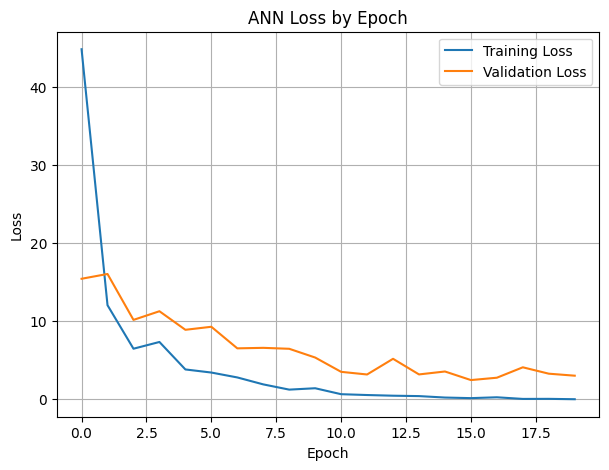

In [ ]:
loss_plot(ann_history)

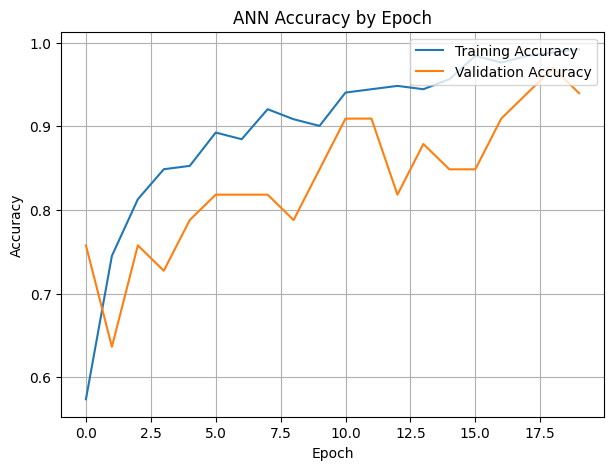

In [ ]:
acc_plot(ann_history)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Train Report:
               precision    recall  f1-score   support

           0       0.47      0.47      0.47       111
           1       0.23      0.23      0.23        70
           2       0.19      0.19      0.19        70

    accuracy                           0.32       251
   macro avg       0.29      0.29      0.29       251
weighted avg       0.32      0.32      0.32       251

Validation Report:
               precision    recall  f1-score   support

           0       0.61      0.58      0.59        19
           1       0.12      0.12      0.12         8
           2       0.29      0.33      0.31         6

    accuracy                           0.42        33
   macro avg       0.34      0.35      0.34        33
weighted avg       0.43      0.42      0.43        33



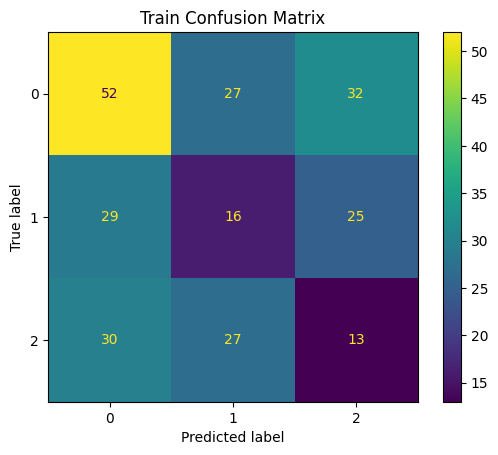

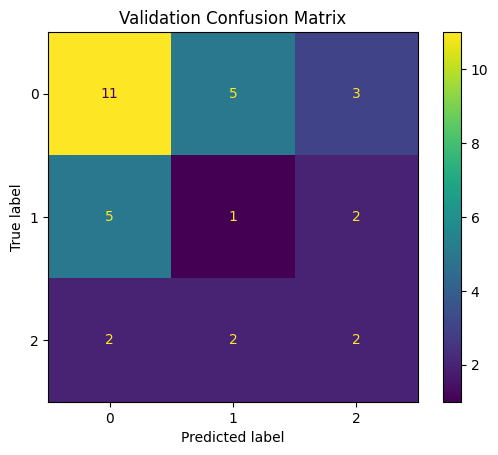

In [ ]:
ann_metrics = model_metrics(ann, train_norm, y_train, val_norm, y_val, conf_mat=True, class_report=True, test_set='Validation')

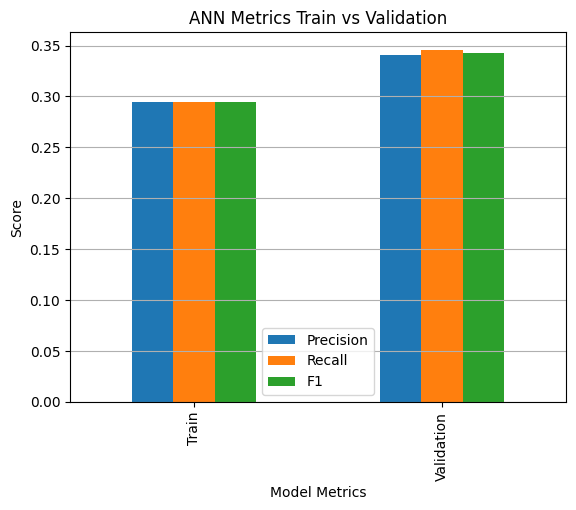

In [ ]:
plot_metrics(ann_metrics, model_type='ANN', test_set='Validation')

# Baseline CNN

In [ ]:
def build_baseline_cnn(input_shape):
  # Build the model
  base_cnn = keras.Sequential([
      # Convolution and Pooling
      layers.Conv2D(16,3,padding='same',activation='relu',input_shape=(256,256,3)),
      layers.MaxPooling2D(),
      layers.Flatten(),
      # Neural Network
      layers.Dense(128, activation='relu'),
      layers.Dense(3, activation='softmax')
  ])

  # Compile the Model
  base_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return base_cnn

In [ ]:
# Build the model
base_cnn = keras.Sequential([
    # Convolution and Pooling
    layers.Conv2D(16,3,padding='same',activation='relu',input_shape=(256,256,3)),
    layers.MaxPooling2D(),
    layers.Flatten(),
    # Neural Network
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# Compile the Model
base_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## CNN Overview
base_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,555,395 (128.00 MB)

 Trainable params: 33,555,395 (128.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the Model
base_cnn_history = base_cnn.fit(train_norm, epochs=20, batch_size=32, validation_data=val_norm)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.4511 - loss: 19.0762 - val_accuracy: 0.5455 - val_loss: 9.9762
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5472 - loss: 8.3296 - val_accuracy: 0.7273 - val_loss: 4.2972
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.6966 - loss: 2.6970 - val_accuracy: 0.6061 - val_loss: 2.7299
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.8660 - loss: 0.6468 - val_accuracy: 0.7879 - val_loss: 1.1871
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9564 - loss: 0.1459 - val_accuracy: 0.7576 - val_loss: 0.8888
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9673 - loss: 0.0769 - val_accuracy: 0.8182 - val_loss: 0.6632
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9674 - loss: 0.0733 - val_accuracy: 0.9091 - val_loss: 0.5280
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9091 - val_loss

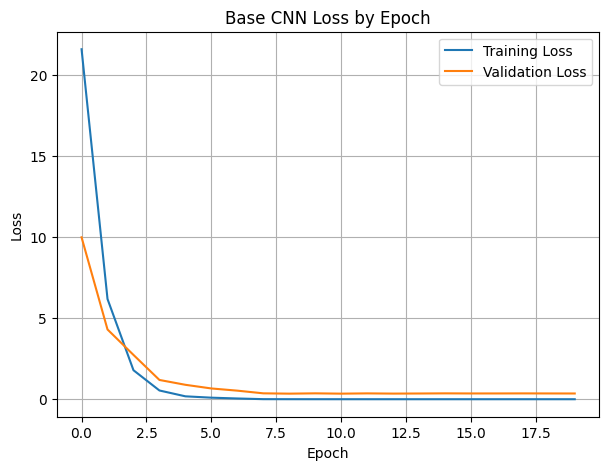

In [ ]:
loss_plot(base_cnn_history, model = 'Base CNN')

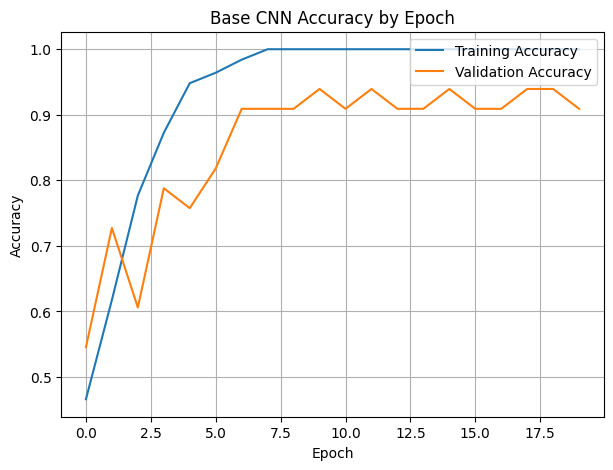

In [ ]:
acc_plot(base_cnn_history, model = 'Base CNN')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
Training Report:
               precision    recall  f1-score   support

           0       0.43      0.43      0.43       111
           1       0.31      0.31      0.31        70
           2       0.21      0.21      0.21        70

    accuracy                           0.34       251
   macro avg       0.32      0.32      0.32       251
weighted avg       0.34      0.34      0.34       251

Validation Report:
               precision    recall  f1-score   support

           0       0.63      0.63      0.63        19
           1       0.25      0.25      0.25         8
           2       0.17      0.17      0.17         6

    accuracy                           0.45        33
   macro avg       0.35      0.35      0.35        33
weighted avg       0.45      0.45      0.45        33



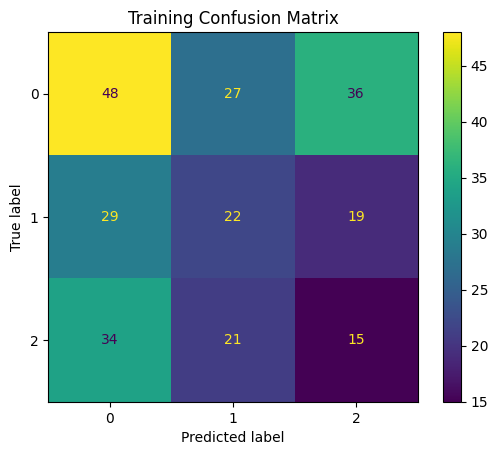

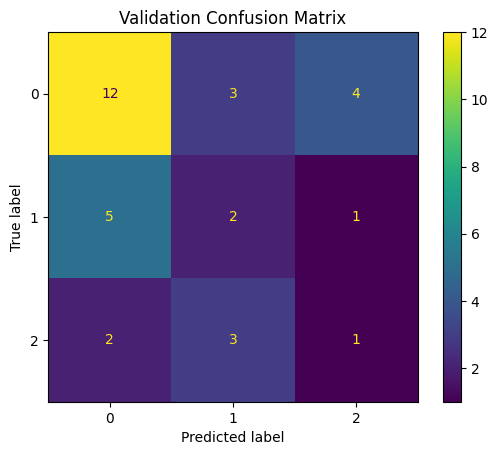

In [ ]:
base_cnn_metrics = model_metrics(base_cnn, train_norm, y_train, val_norm, y_val, class_report=True, conf_mat=True,
                                 test_set='Validation')

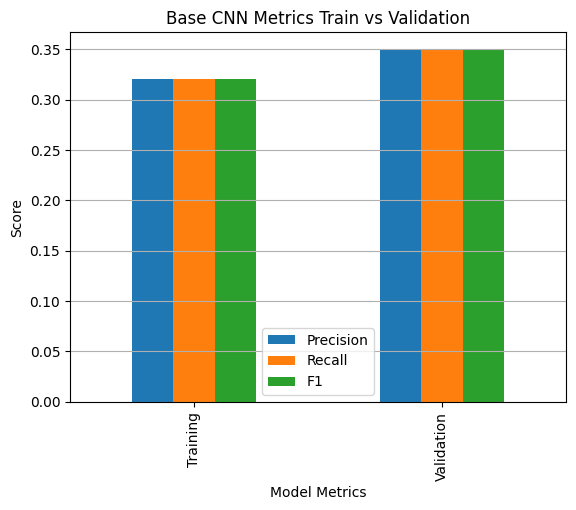

In [ ]:
plot_metrics(base_cnn_metrics, model_type='Base CNN', test_set='Validation')

# Adjust Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.7537537537537538),
 1: np.float64(1.1952380952380952),
 2: np.float64(1.1952380952380952)}

# Data Augmentation

In [ ]:
def clahe_im(image): # Function to apply CLAHE to images
  im_np = image.numpy() # Convert image to numpy array for OpeCV
  im_np = im_np.astype(np.uint8) # Ensure data type is uint8 for OpenCV
  im_gray = cv2.cvtColor(im_np, cv2.COLOR_RGB2GRAY) # Convert to grayscale for OpenCV
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # Create CLAHE object
  im_clahe_gray = clahe.apply(im_gray) # Apply CLAHE to grayscale image
  im_clahe_rgb = cv2.cvtColor(im_clahe_gray, cv2.COLOR_GRAY2RGB) # Convert image back to RGB
  aug = tf.convert_to_tensor(im_clahe_rgb, dtype=tf.float32) # Convert back to Tensor
  #aug = tf.image.random_brightness(aug, max_delta=0.2) # Alter brightness
  return aug

In [ ]:
def map_func(image, label): # Function to apply tf map function to images stored as numpy arrays
  im = tf.py_function(func=clahe_im, # apply clahe function
   inp=[image], # input image to augment
   Tout=tf.float32) # return tf.float32 image
  im.set_shape([256,256,3]) # specify image output shape
  return im, label

In [ ]:
def minority_subset(ds, class_label, num_augments):
  ds_c = ds.shuffle(1000, seed=5) # Shuffle the data
  ds_c = ds_c.filter(lambda im, label: tf.equal(label, class_label)) # extract the [class_label] images
  ds_c = ds_c.take(num_augments) # Take a random subset of [num_augments] images to augment
  return ds_c

In [ ]:
def augment_image(image, label, target_label):
  if label == target_label:
    #aug = tf.image.random_flip_left_right(image) # Random horizonal flip
    #aug = tf.image.random_flip_up_down(aug) # Random vertical flip
    aug = tf.image.random_brightness(aug, max_delta=0.2)
    aug = tf.image.random_contrast(aug, lower=0.9, upper=1.0)
  else:
    aug = image
  aug = tf.image.resize(aug, (256,256))
  return aug, label # Return augmented image

In [ ]:
def apply_augmentation(ds, batch_size=16):
  ds = ds.unbatch()
  ds = ds.map(lambda x, y: map_func(x, y))
  ds = ds.batch(batch_size)
  ds = ds.map(lambda x, y: (normalization_layer(x), y))
  return ds

In [ ]:
# @title
## Number of samples for each class
majority_count = int((y_train == 0).sum())
normal_count = int((y_train == 1).sum())
pneumonia_count = int((y_train == 2).sum())

In [ ]:
print([majority_count, normal_count, pneumonia_count])
print([majority_count/251, normal_count/251, pneumonia_count/251])

[111, 70, 70]
[0.44223107569721115, 0.2788844621513944, 0.2788844621513944]


In [ ]:
# @title
## Get a subset of covid images
num_augments = majority_count - normal_count ## Number of new images to make
train = train.unbatch() ## Unbatch training set
train_normal = minority_subset(train, 1, num_augments) ## subset of [num_augments] normal images to augment

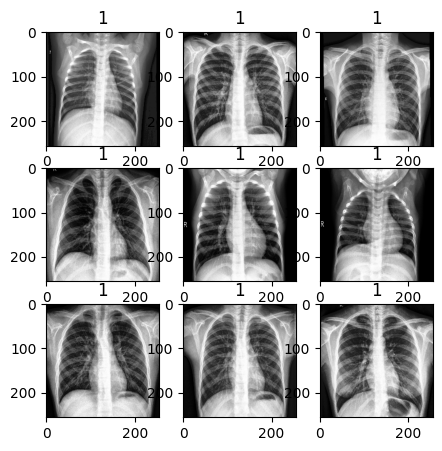

In [ ]:
# @title
display_images(train_normal) # Normal images before augmentation

In [ ]:
# @title
## Apply augmentation to Normal subset
train_normal = train_normal.map(lambda x,y: map_func(x,y)) ## Augment the subset of images
train_aug = train.concatenate(train_normal) ## Add in the new augmented images

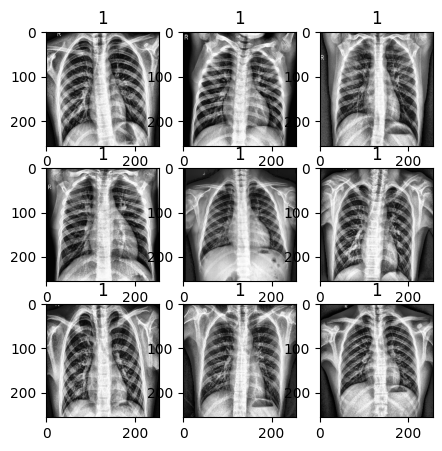

In [ ]:
# @title
display_images(train_normal) # Normal images after augmentation

In [ ]:
# @title
## Augment Pneumonia Images

num_augments = majority_count - pneumonia_count ## Number of new images to make

train_pn = minority_subset(train, 2, num_augments) ## subset of [num_augments] pnuemonia images to augment

train_pn = train_pn.map(lambda x,y: map_func(x,y)) ## Augment the subset of images
train_aug = train_aug.concatenate(train_pn) ## Add in the new augmented images

In [ ]:
# @title
#train = train.shuffle(1000, seed=5)
train_aug = train_aug.batch(batch_size=32)
train_aug = train_aug.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
train_aug  = apply_augmentation(train, batch_size=16)
#val_aug = apply_augmentation(val, batch_size=16)
#test_aug = apply_augmentation(test, batch_size=16)

In [ ]:
#display_images(train_aug)

In [ ]:
# @title
y_train_list = []
# Unbatch train_aug to get individual (image, label) pairs
# This avoids IteratorGetNext complaining about variable batch sizes
for _, label in train_aug.unbatch():
  y_train_list.append(label.numpy())
y_train = np.array(y_train_list) # Convert list of individual labels to a single numpy array

In [ ]:
y_val_list = []
for _, label in val_aug.unbatch():
  y_val_list.append(label.numpy())
y_val = np.array(y_val_list)

y_test_list = []
for _, label in test_aug.unbatch():
  y_test_list.append(label.numpy())
y_test = np.array(y_test_list)

# Retry Baseline

In [ ]:
base_cnn = build_baseline_cnn(input_shape=(256,256,3))
base_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,555,395 (128.00 MB)

 Trainable params: 33,555,395 (128.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_cnn_history_aug = base_cnn.fit(train_aug, epochs=20, batch_size=32, validation_data=val_norm)

Epoch 1/20
     11/Unknown 7s 466ms/step - accuracy: 0.3975 - loss: 22.4019

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 540ms/step - accuracy: 0.4024 - loss: 22.0905 - val_accuracy: 0.5455 - val_loss: 2.9821
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.7054 - loss: 1.0055 - val_accuracy: 0.6061 - val_loss: 1.3421
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - accuracy: 0.7466 - loss: 1.1621 - val_accuracy: 0.7273 - val_loss: 1.0616
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.8924 - loss: 0.2741 - val_accuracy: 0.8182 - val_loss: 0.7346
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 0.9432 - loss: 0.1685 - val_accuracy: 0.8788 - val_loss: 0.4592
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.9889 - loss: 0.0408 - val_accuracy: 0.9394 - val_loss: 0.3617
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - accuracy: 0.9945 - loss: 0.0174 - val_accuracy: 0.9091 - val_loss: 0.3056
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.9091 - val

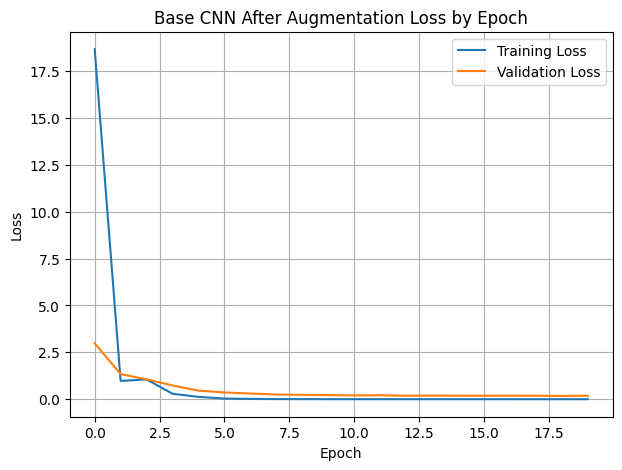

In [ ]:
loss_plot(base_cnn_history_aug, model='Base CNN After Augmentation')

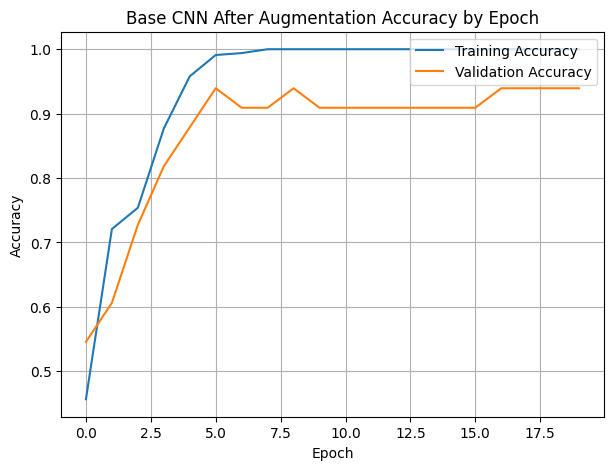

In [ ]:
acc_plot(base_cnn_history_aug, model='Base CNN After Augmentation')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
Training Report:
               precision    recall  f1-score   support

           0       0.43      0.43      0.43       111
           1       0.26      0.26      0.26        70
           2       0.29      0.29      0.29        70

    accuracy                           0.34       251
   macro avg       0.33      0.33      0.33       251
weighted avg       0.34      0.34      0.34       251

Validation Report:
               precision    recall  f1-score   support

           0       0.65      0.68      0.67        19
           1       0.29      0.25      0.27         8
           2       0.50      0.50      0.50         6

    accuracy                           0.55        33
   macro avg       0.48      0.48      0.48        33
weighted avg       0.53      0.55      0.54        33



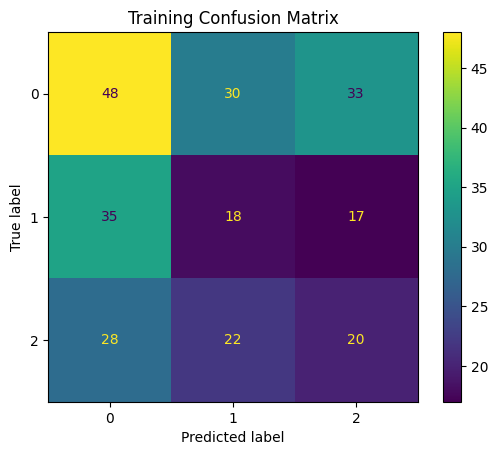

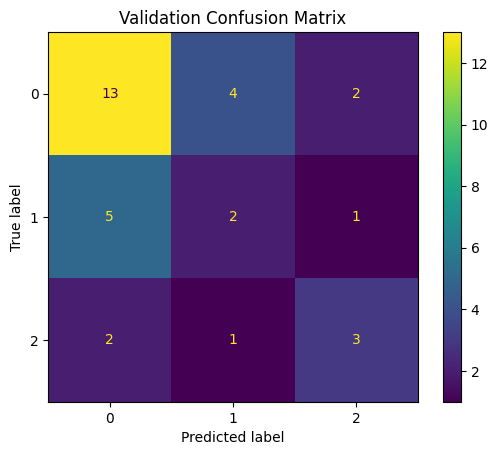

In [ ]:
base_cnn_metrics_aug = model_metrics(base_cnn,train_norm,y_train,val_norm,y_val,class_report=True,conf_mat=True,test_set='Validation')

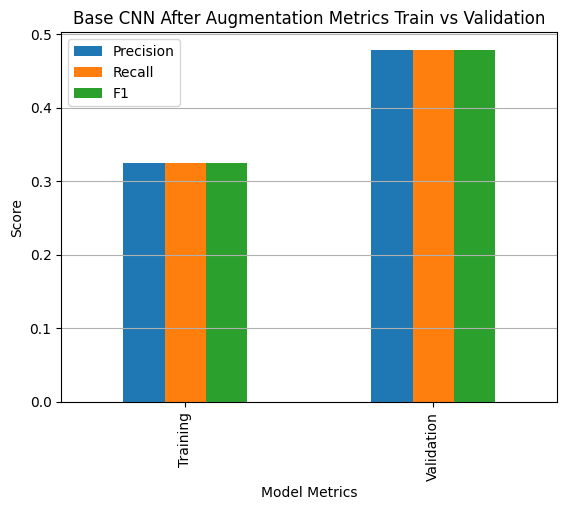

In [ ]:
plot_metrics(base_cnn_metrics_aug, model_type='Base CNN After Augmentation', test_set='Validation')

# Second CNN Model

In [ ]:
# Build the Model
cnn_2 = keras.Sequential([
    # Convolution and Pooling
    layers.Conv2D(16,(3,3),padding='same',activation='relu',input_shape=(256,256,3)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),

    # Neural Network
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')

])

#cnn_2.add(Dropout(0.3))

# Optimizer
opt = Adam(learning_rate=0.0001)

# Compile model
cnn_2.compile(optimizer=opt, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model Summary
cnn_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,790,883 (64.05 MB)

 Trainable params: 16,790,883 (64.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit model
cnn_2_history = cnn_2.fit(train_aug, epochs=20, batch_size=32, validation_data=val_norm)

Epoch 1/20
     11/Unknown 6s 263ms/step - accuracy: 0.5428 - loss: 1.1089

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 365ms/step - accuracy: 0.5419 - loss: 1.1027 - val_accuracy: 0.2727 - val_loss: 1.4025
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step - accuracy: 0.4526 - loss: 1.0745 - val_accuracy: 0.7273 - val_loss: 0.7124
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 0.8009 - loss: 0.5831 - val_accuracy: 0.6970 - val_loss: 0.6135
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step - accuracy: 0.8581 - loss: 0.4288 - val_accuracy: 0.7273 - val_loss: 0.5967
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.8764 - loss: 0.3601 - val_accuracy: 0.7576 - val_loss: 0.5263
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.9106 - loss: 0.2728 - val_accuracy: 0.7879 - val_loss: 0.4945
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 0.9328 - loss: 0.2474 - val_accuracy: 0.8182 - val_loss: 0.4249
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step - accuracy: 0.9351 - loss: 0.2128 - val_accuracy: 0.8485 - val_

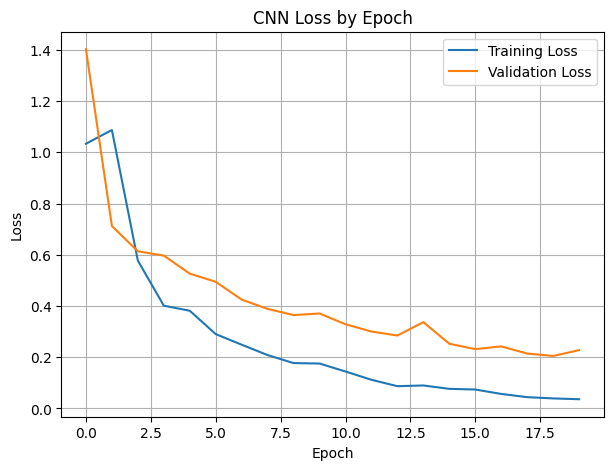

In [ ]:
loss_plot(cnn_2_history, model='CNN')

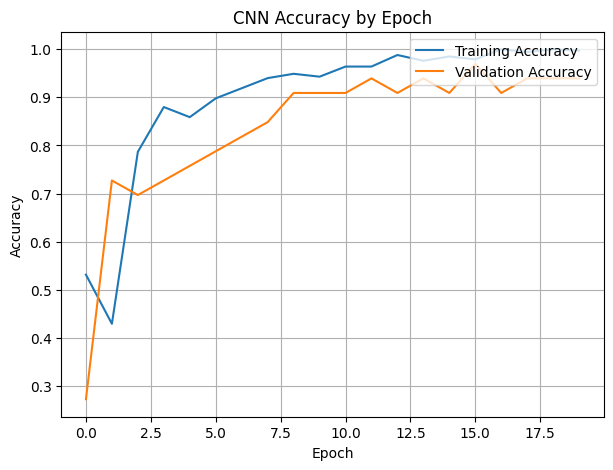

In [ ]:
acc_plot(cnn_2_history, model='CNN')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Training Report:
               precision    recall  f1-score   support

           0       0.39      0.39      0.39       111
           1       0.34      0.34      0.34        70
           2       0.25      0.24      0.24        70

    accuracy                           0.33       251
   macro avg       0.32      0.32      0.32       251
weighted avg       0.33      0.33      0.33       251

Validation Report:
               precision    recall  f1-score   support

           0       0.48      0.53      0.50        19
           1       0.25      0.25      0.25         8
           2       0.25      0.17      0.20         6

    accuracy                           0.39        33
   macro avg       0.33      0.31      0.32        33
weighted avg       0.38      0.39      0.38        33



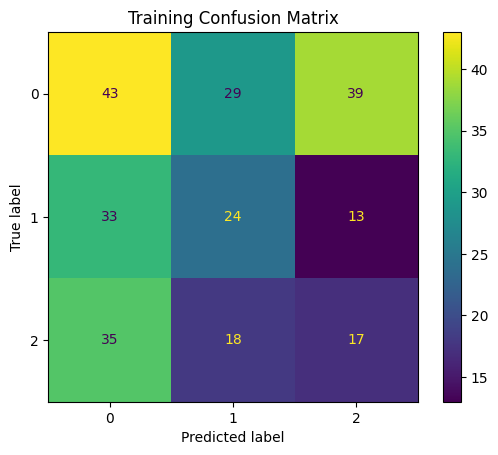

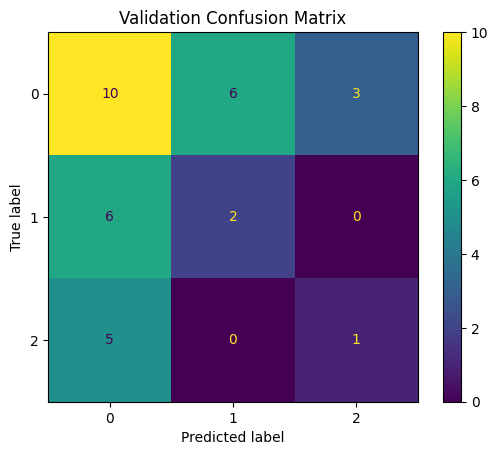

In [ ]:
cnn_2_metrics = model_metrics(cnn_2, train_norm, y_train, val_norm, y_val, class_report=True, conf_mat=True,
                              test_set = 'Validation')

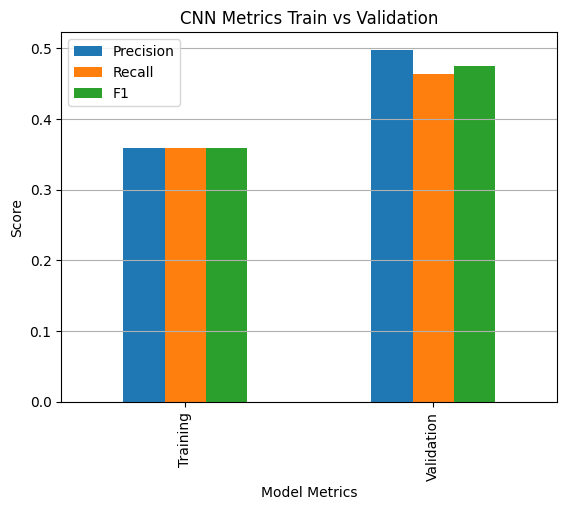

In [ ]:
plot_metrics(cnn_2_metrics, model_type='CNN', test_set='Validation')

# Transfer Learning

## VGG16

In [ ]:
from tensorflow.keras.applications import VGG16, DenseNet201

In [ ]:
y_train_vgg = []
for im, label in train_aug: # Get the labels from each batch
  y_train_vgg.append(label) # store the labels in y_train
y_train_vgg = np.concatenate(y_train_vgg, axis=0) # Concatenate the batches' labels

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
for layer in base_model.layers:
    layer.trainable=False

In [ ]:
vgg = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

#opt = Adam(learning_rate=0.0001)

vgg.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
vgg_history = vgg.fit(train_aug, epochs=10, batch_size=32, validation_data=val_norm, class_weight=class_weights)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.4084 - loss: 1.3510 - val_accuracy: 0.6061 - val_loss: 0.8637
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.6735 - loss: 0.8917 - val_accuracy: 0.7576 - val_loss: 0.8051
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.5856 - loss: 0.9027 - val_accuracy: 0.8182 - val_loss: 0.6896
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.6885 - loss: 0.8090 - val_accuracy: 0.7576 - val_loss: 0.5830
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.7704 - loss: 0.6092 - val_accuracy: 0.7879 - val_loss: 0.5293
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.8459 - loss: 0.5042 - val_accuracy: 0.7879 - val_loss: 0.4825
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8432 - loss: 0.4632 - val_accuracy: 0.8182 - val_loss: 0.4500
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.8611 - loss: 0.4418 - val_accuracy: 0.

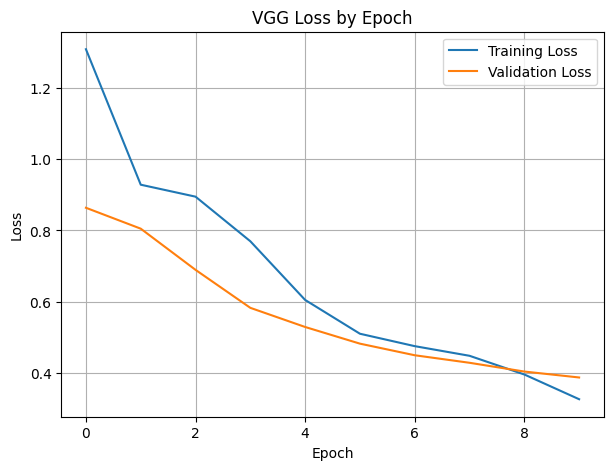

In [ ]:
loss_plot(vgg_history, model='VGG')

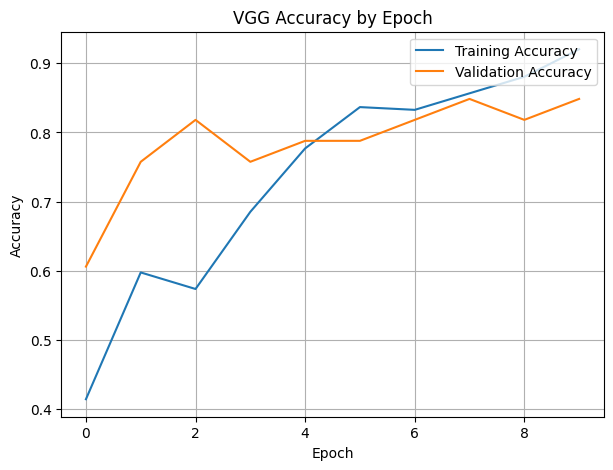

In [ ]:
acc_plot(vgg_history, model='VGG')

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
Training Report:
               precision    recall  f1-score   support

           0       0.41      0.38      0.39       111
           1       0.28      0.31      0.29        70
           2       0.28      0.27      0.28        70

    accuracy                           0.33       251
   macro avg       0.32      0.32      0.32       251
weighted avg       0.33      0.33      0.33       251

Validation Report:
               precision    recall  f1-score   support

           0       0.55      0.58      0.56        19
           1       0.25      0.12      0.17         8
           2       0.11      0.17      0.13         6

    accuracy                           0.39        33
   macro avg       0.30      0.29      0.29        33
weighted avg       0.40      0.39      0.39        33



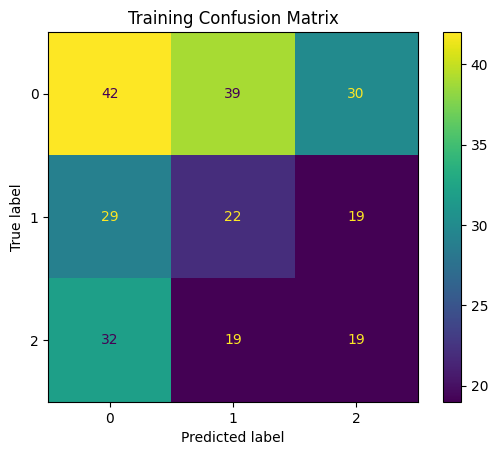

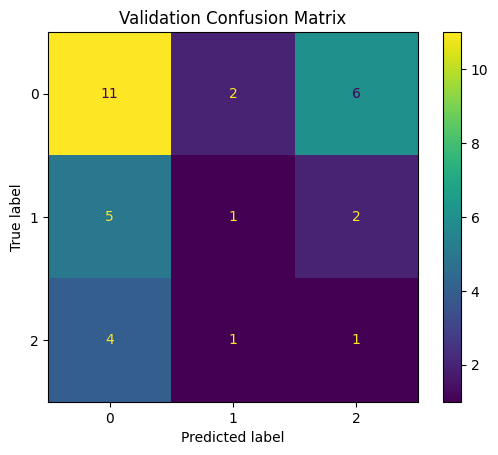

In [ ]:
vgg_metrics = model_metrics(vgg, train_aug, y_train, val_norm, y_val, class_report=True, conf_mat=True, test_set='Validation')

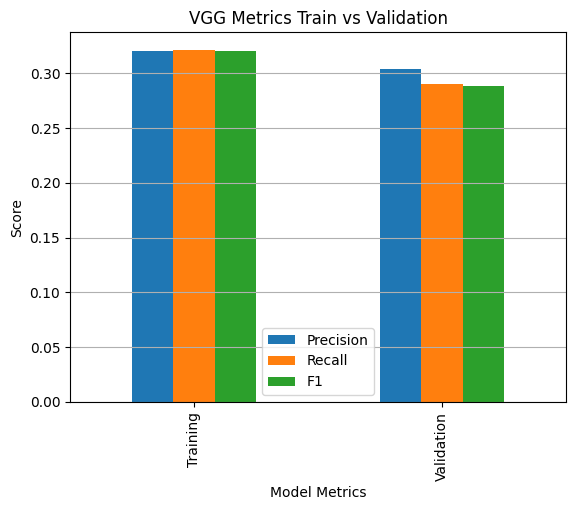

In [ ]:
plot_metrics(vgg_metrics, test_set = 'Validation', model_type='VGG')

## DenseNet201

In [ ]:
## Rebatch images to smaller batches
train_norm_dn = train_norm.rebatch(batch_size=32)
val_norm_dn = val.rebatch(batch_size=32)

In [ ]:
# Resize images to (224,224) for DenseNet
resizing_layer = keras.layers.Resizing(224, 224)
train_norm_dn = train_norm_dn.map(lambda x, y: (resizing_layer(x), y))
val_norm_dn = val_norm_dn.map(lambda x, y: (resizing_layer(x), y))

In [ ]:
# Define DenseNet201 base Model and freeze layers
base_model_dn = DenseNet201(weights = 'imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model_dn.layers:
  layer.trainable = False

In [ ]:
dn = keras.Sequential([
    base_model_dn,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

dn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

dn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 94080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    12,042,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,364,739 (115.83 MB)

 Trainable params: 12,042,755 (45.94 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
dn_history = dn.fit(train_norm_dn, batch_size=32, epochs=10, validation_data=val_norm_dn)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step - accuracy: 0.6234 - loss: 8.0792 - val_accuracy: 0.3333 - val_loss: 13.5510
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 487ms/step - accuracy: 0.9182 - loss: 1.4756 - val_accuracy: 0.5758 - val_loss: 58.0808
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 470ms/step - accuracy: 0.9641 - loss: 0.6227 - val_accuracy: 0.5758 - val_loss: 39.2712
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 496ms/step - accuracy: 0.9877 - loss: 0.1011 - val_accuracy: 0.5758 - val_loss: 64.8748
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 0.5758 - val_loss: 91.8243
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 468ms/step - accuracy: 0.9886 - loss: 0.0506 - val_accuracy: 0.5758 - val_loss: 68.5323
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step - accuracy: 1.0000 - loss: 4.7786e-06 - val_accuracy: 0.5758 - val_loss: 63.0533
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 476ms/step - accuracy: 1.0000 - loss: 9.3103e-07 - va

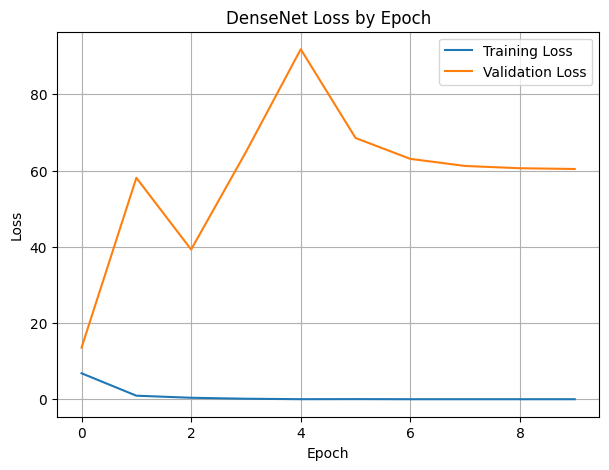

In [ ]:
loss_plot(dn_history, model='DenseNet')

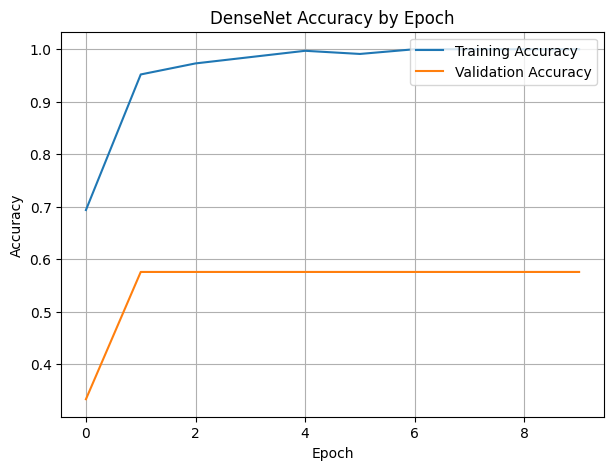

In [ ]:
acc_plot(dn_history, model='DenseNet')

11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 14s/step
Train Report:
               precision    recall  f1-score   support

           0       0.47      0.47      0.47       111
           1       0.59      0.59      0.59       111
           2       0.56      0.56      0.56       111

    accuracy                           0.54       333
   macro avg       0.54      0.54      0.54       333
weighted avg       0.54      0.54      0.54       333

Validation Report:
               precision    recall  f1-score   support

           0       0.56      0.95      0.71        19
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         6

    accuracy                           0.55        33
   macro avg       0.19      0.32      0.24        33
weighted avg       0.32      0.55      0.41        33



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

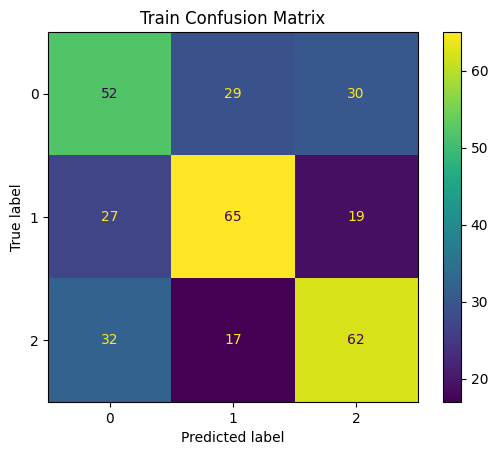

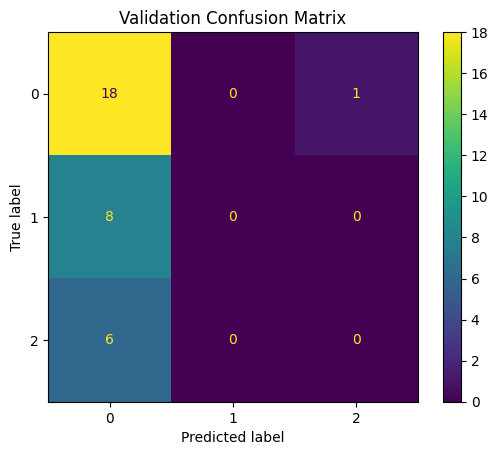

In [ ]:
dn_metrics = model_metrics(dn, train_norm_dn, y_train, val_norm_dn, y_val, class_report=True, conf_mat=True, test_set='Validation')

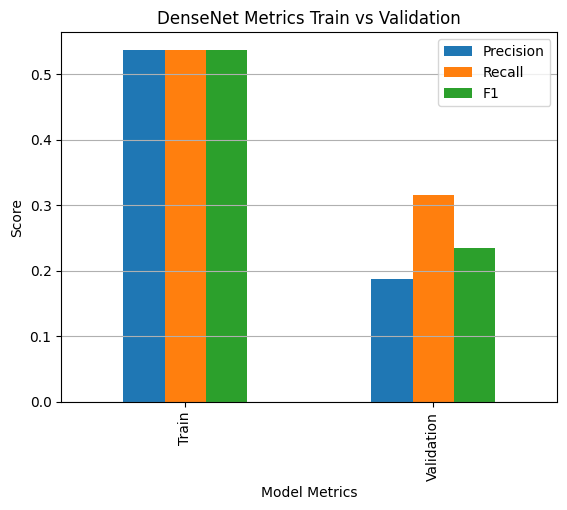

In [ ]:
plot_metrics(dn_metrics, test_set='Validation', model_type='DenseNet')

## Unfreeze VGG Layers

In [ ]:
base_vgg_4 = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
for i in range(len(base_vgg_4.layers)-4):
    base_vgg_4.layers[i].trainable=False

In [ ]:
vgg_4 = keras.Sequential([
    base_vgg_4,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

opt = Adam(learning_rate=0.001)

vgg_4.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
vgg_4_history = vgg_4.fit(train_norm, epochs=20, batch_size=32, validation_data=val_norm)

Epoch 1/20
     11/Unknown 14s 650ms/step - accuracy: 0.3929 - loss: 1.9972

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 814ms/step - accuracy: 0.3982 - loss: 1.9781 - val_accuracy: 0.1818 - val_loss: 17.1474
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 571ms/step - accuracy: 0.3379 - loss: 4.9543 - val_accuracy: 0.1818 - val_loss: 1.1187
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 514ms/step - accuracy: 0.2796 - loss: 1.1290 - val_accuracy: 0.5758 - val_loss: 1.0974
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.4488 - loss: 1.0953 - val_accuracy: 0.1818 - val_loss: 2.5720
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step - accuracy: 0.3438 - loss: 1.3178 - val_accuracy: 0.2424 - val_loss: 1.0981
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 519ms/step - accuracy: 0.3087 - loss: 1.0986 - val_accuracy: 0.2424 - val_loss: 1.0987
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - accuracy: 0.2656 - loss: 1.0988 - val_accuracy: 0.1818 - val_loss: 1.0995
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 495ms/step - accuracy: 0.2762 - loss: 1.0990 - val_accuracy: 0.1818 - va

## Unfreeze DenseNet Layers

In [ ]:
# Resize images to (224,224) for DenseNet
resizing_layer = keras.layers.Resizing(224, 224)
train_dn = train_aug.map(lambda x, y: (resizing_layer(x), y))
val_dn = val_aug.map(lambda x, y: (resizing_layer(x), y))

In [ ]:
base_dn_40 = DenseNet201(weights = 'imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_dn_40.layers[:-40]:
  layer.trainable = False

In [ ]:
sum(layer.trainable for layer in base_dn_40.layers)

40

In [ ]:
dn_40 = keras.Sequential([
    base_dn_40,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

opt = Adam(learning_rate=0.001)

dn_40.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

dn_40.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 94080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    12,042,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,364,739 (115.83 MB)

 Trainable params: 13,454,659 (51.33 MB)

 Non-trainable params: 16,910,080 (64.51 MB)

In [ ]:
dn_40_history = dn_40.fit(train_dn, batch_size=32, epochs=10, validation_data=val_dn,
                          class_weight=class_weights)

Epoch 1/10
      8/Unknown 98s 5s/step - accuracy: 0.3487 - loss: 26.1015   

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - accuracy: 0.3507 - loss: 25.9263 - val_accuracy: 0.7576 - val_loss: 2.4464
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.9440 - loss: 0.3904 - val_accuracy: 0.7879 - val_loss: 2.8129
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.9421 - loss: 0.2477 - val_accuracy: 0.7879 - val_loss: 1.1648
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.9834 - loss: 0.0615 - val_accuracy: 0.8485 - val_loss: 0.6978
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.9875 - loss: 0.0969 - val_accuracy: 0.8788 - val_loss: 0.5340
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.9875 - loss: 0.0381 - val_accuracy: 0.9394 - val_loss: 0.1177
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.9887 - loss: 0.0487 - val_accuracy: 0.9091 - val_loss: 0.6813
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.9936 - loss: 0.0134 - val_accuracy: 0.9091 - val_loss: 0.5784
Ep

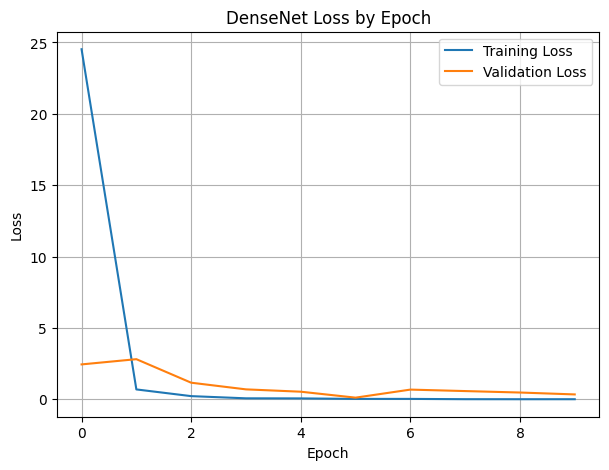

In [ ]:
loss_plot(dn_40_history, model='DenseNet')

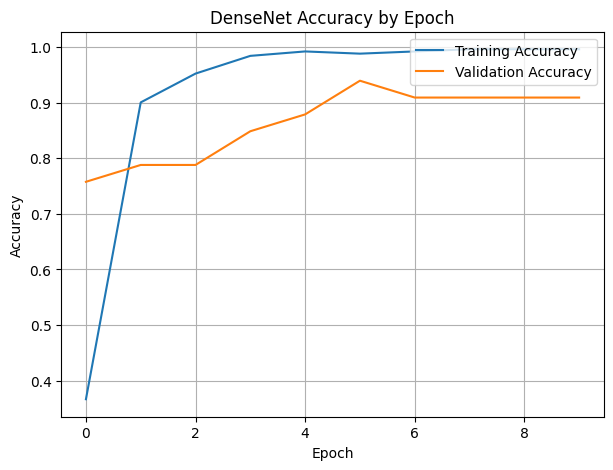

In [ ]:
acc_plot(dn_40_history, model='DenseNet')

8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Train Report:
               precision    recall  f1-score   support

           0       0.38      0.37      0.38       111
           1       0.31      0.33      0.32        70
           2       0.20      0.20      0.20        70

    accuracy                           0.31       251
   macro avg       0.30      0.30      0.30       251
weighted avg       0.31      0.31      0.31       251

Validation Report:
               precision    recall  f1-score   support

           0       0.62      0.53      0.57        19
           1       0.27      0.38      0.32         8
           2       0.17      0.17      0.17         6

    accuracy                           0.42        33
   macro avg       0.35      0.36      0.35        33
weighted avg       0.46      0.42      0.44        33



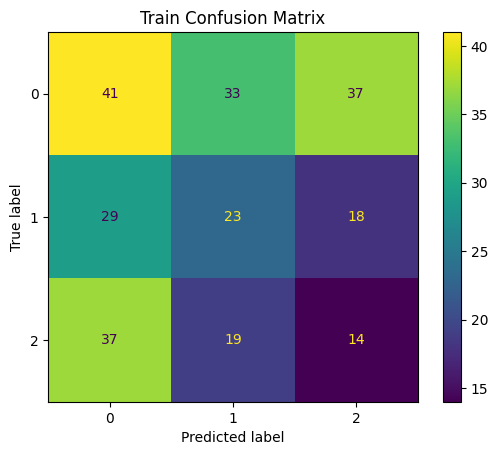

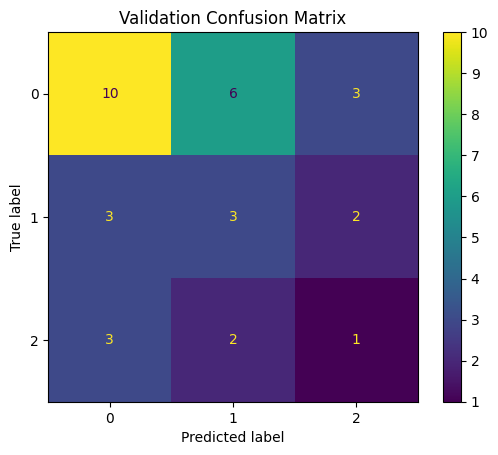

In [ ]:
dn_metrics = model_metrics(dn_40, train_dn, y_train, val_dn, y_val, class_report=True, conf_mat=True, test_set='Validation')

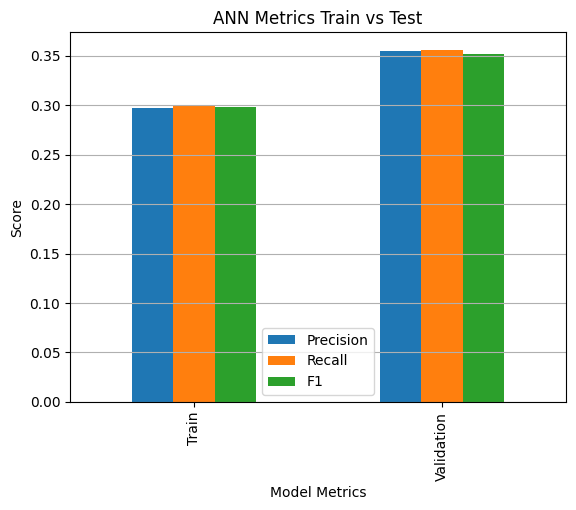

In [ ]:
plot_metrics(dn_metrics)

# Professor's Work

In [ ]:
img_size = (224, 224)
batch_size = 16

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    shear_range=0.1,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_aug = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_gen = test_aug.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [ ]:
labels = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.7528089887640449),
 1: np.float64(1.1964285714285714),
 2: np.float64(1.1964285714285714)}

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
# Load pretrained DenseNet201
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model for transfer learning
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,327,747 (69.91 MB)

 Trainable params: 5,763 (22.51 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Keep most layers frozen (freeze all except the last 40)
for layer in base_model.layers[:-40]:
    layer.trainable = False

print("Trainable layers:", sum([layer.trainable for layer in model.layers]))

Trainable layers: 43


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.3643 - loss: 1.3361 - val_accuracy: 0.3600 - val_loss: 1.1274
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 632ms/step - accuracy: 0.3486 - loss: 1.3132 - val_accuracy: 0.3600 - val_loss: 1.0752
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 624ms/step - accuracy: 0.4869 - loss: 1.1015 - val_accuracy: 0.5000 - val_loss: 1.0048
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.4780 - loss: 1.1596 - val_accuracy: 0.5200 - val_loss: 0.9813
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 632ms/step - accuracy: 0.5012 - loss: 1.1155 - val_accuracy: 0.4200 - val_loss: 0.9992
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 616ms/step - accuracy: 0.5704 - loss: 0.9520 - val_accuracy: 0.5600 - val_loss: 0.9238
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 628ms/step - accuracy: 0.5968 - loss: 0.8936 - val_accuracy: 0.7000 - val_loss: 0.8434
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 613ms/step - accuracy: 0.5614 - loss: 1.0130 - val_accuracy: 0.5

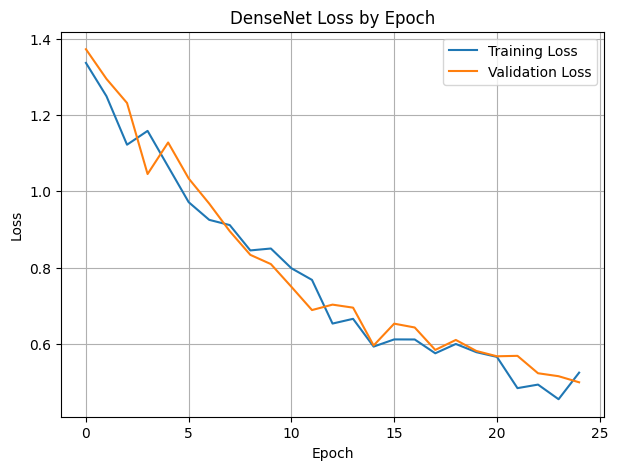

In [ ]:
loss_plot(history_ft, model="DenseNet")

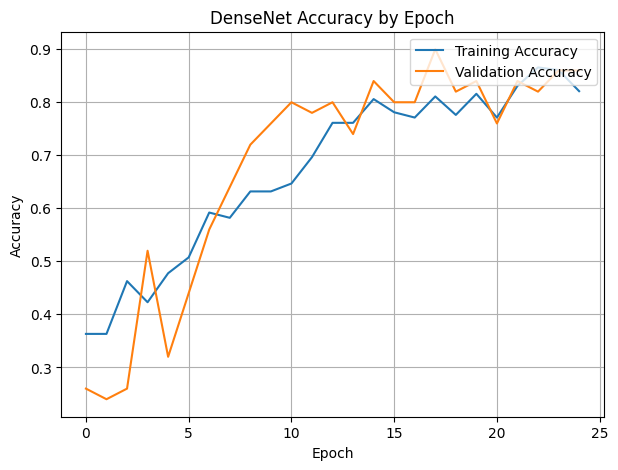

In [ ]:
acc_plot(history_ft, model='DenseNet')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
                 precision    recall  f1-score   support

          Covid       1.00      0.92      0.96        26
         Normal       0.80      0.80      0.80        20
Viral Pneumonia       0.82      0.90      0.86        20

       accuracy                           0.88        66
      macro avg       0.87      0.87      0.87        66
   weighted avg       0.88      0.88      0.88        66



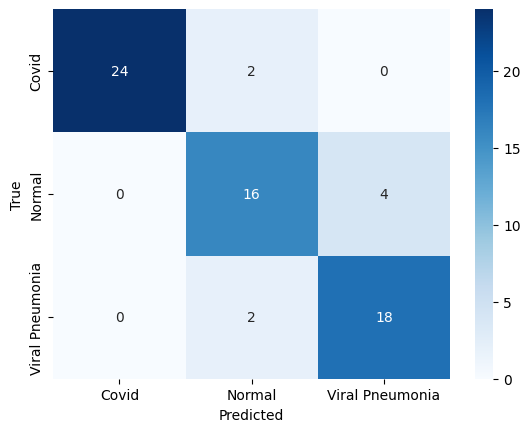

In [ ]:
import seaborn as sns

test_pred = model.predict(test_gen)
y_pred = test_pred.argmax(axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step
Validation Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.82      1.00      0.90        14
           2       1.00      0.86      0.92        14

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50

Test Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.73      0.80      0.76        20
           2       0.80      0.80      0.80        20

    accuracy                           0.83        66
   macro avg       0.83      0.83      0.83        66
weighted avg       0.84      0.83      0.84        66



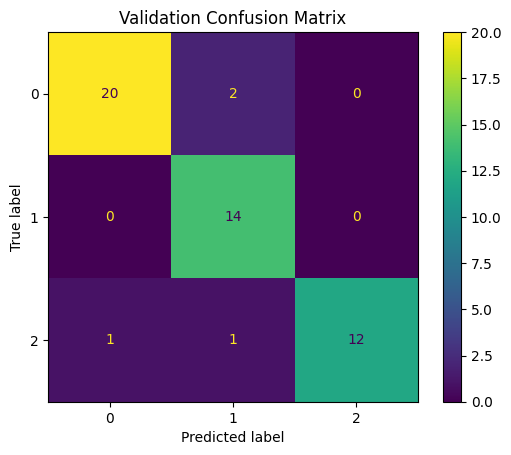

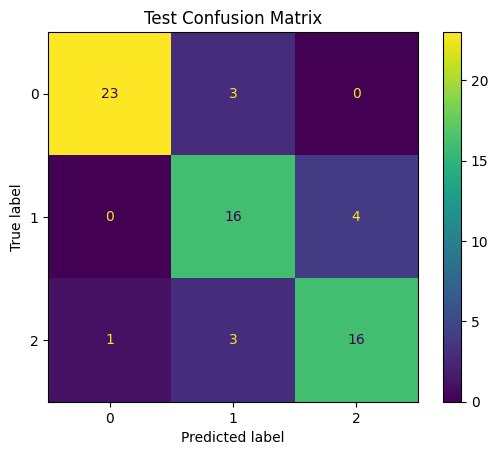

In [ ]:
metrics = model_metrics(model, val_gen, val_gen.classes, test_gen, test_gen.classes,
              class_report=True, conf_mat=True,
                        test_set = 'Test',
                        train_set='Validation')

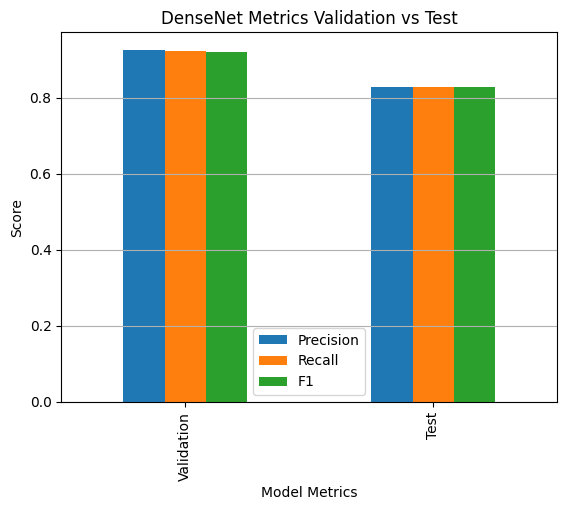

In [ ]:
plot_metrics(metrics, model_type='DenseNet', train_set='Validation', test_set='Test')

In [ ]:
train_gen.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2], dtype=int32)

In [ ]:
train_gen

In [ ]:
train_norm

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
y_true = val_gen.classes
f1_val_dist = []
for i in range(30):
  val_preds = model.predict(val_gen)
  y_pred = val_preds.argmax(axis=1)
  val_f1 = f1_score(y_true, y_pred, average='macro')
  f1_val_dist.append(val_f1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 395ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 407ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 407ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
f1_avg_val = round(np.mean(f1_val_dist),2)
f1_med_val = round(np.median(f1_val_dist),2)
f1_std_val = round(np.std(f1_val_dist),2)
f1_var_val = round(np.var(f1_val_dist),2)
f1_range_val = round(max(f1_val_dist) - min(f1_val_dist),2)

In [ ]:
print(f1_avg_val, f1_med_val, f1_std_val, f1_range_val)

0.85 0.85 0.03 0.12


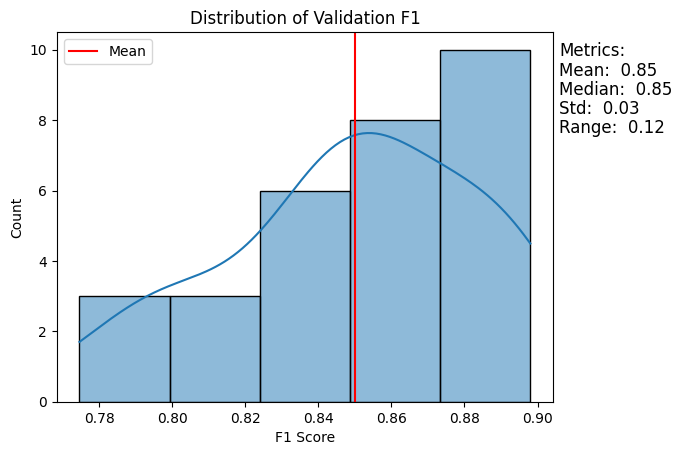

In [ ]:
import seaborn as sns
sns.histplot(f1_val_dist, kde=True, bins=5)
plt.title('Distribution of Validation F1')
plt.axvline(f1_avg_val, label='Mean', color='red')
plt.legend()
plt.figtext(0.91,0.83, 'Metrics:', size=12)
plt.figtext(0.91,0.79, f'Mean: {f1_avg_val: 0.2f}', size=12)
plt.figtext(0.91,0.75, f'Median: {f1_med_val: 0.2f}', size=12)
plt.figtext(0.91,0.71, f'Std: {f1_std_val: 0.2f}', size=12)
plt.figtext(0.91,0.67, f'Range: {f1_range_val: 0.2f}', size=12)
plt.xlabel('F1 Score'); plt.ylabel('Count')
plt.show()